# ARTI 403 – Image Processing
## Lab 4 — Intensity Transformations and Filtering (Spatial Domain)

**Student name:** Ahmed Albuainain
**Student ID:** 2240006128
**Section:** 7MA1
**Date:** 5 October 2026

---

### Session Outcome
**Outcome #2:** Write a program that implements fundamental image processing algorithms.

### Contents
| Part | Description |
|---|---|
| Part 0 | Environment check and preparing the images |
| Part 1 | Thresholding — fixed, other types, Otsu, adaptive |
| Part 2 | Histogram processing — contrast stretching (2nd–98th percentiles) |
| Task 1 | Rescale intensities to the 3rd–80th percentiles and plot the histogram |
| Task 2 | Histogram equalisation with `exposure.equalize_hist` |
| Task 3 | Histogram matching — rocket as reference, Chelsea as the input image |

---
## Part 0 — Environment check and preparing the images

The manual reads `../images/Parrot.png`. That file is not distributed with the lab, so the cell
below creates it from a colour sample of `skimage.data`. If the file already exists it is kept,
so an image supplied by the instructor takes priority.

The other three images — `moon`, `rocket` and `chelsea` — come directly from `skimage.data`
and need no files on disk.

In [1]:
import os
import sys
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt

import skimage as ski
from skimage import data, exposure, img_as_float, img_as_ubyte

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("OpenCV      :", cv2.__version__)
print("scikit-image:", ski.__version__)
print("Matplotlib  :", matplotlib.__version__)

%matplotlib inline

Python      : 3.13.5
NumPy       : 2.3.5
OpenCV      : 5.0.0
scikit-image: 0.26.0
Matplotlib  : 3.10.8


In [2]:
# resolve the images folder: '../images' if it exists, otherwise './images'
IMG_DIR = os.path.join("..", "images")
if not os.path.isdir(IMG_DIR):
    IMG_DIR = "images"
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs("output", exist_ok=True)

def img_path(name):
    return os.path.join(IMG_DIR, name)

# a stand-in for Parrot.png: a colour photograph from the skimage samples
if not os.path.exists(img_path("Parrot.png")):
    cv2.imwrite(img_path("Parrot.png"),
                cv2.cvtColor(data.coffee(), cv2.COLOR_RGB2BGR))

print("images folder:", os.path.abspath(IMG_DIR))
print("contents     :", sorted(os.listdir(IMG_DIR)))

images folder: c:\Users\ahmad\OneDrive\Desktop\im Labs\lab1\Lab 4\images
contents     : ['Parrot.png']


### Two display helpers

`cv2.imshow` with `cv2.waitKey(0)` — used in the manual's Task 1 — opens a separate
operating-system window and blocks until a key is pressed. In a notebook the window often
opens behind the browser and closing it with the mouse can leave the kernel stuck. Everything
here is drawn with Matplotlib instead.

The second helper draws an image next to its histogram, which is the pattern the whole of
Part 2 needs. It reads the display range from the array itself rather than assuming 0–255 —
the reason for that becomes important in Task 2.

In [3]:
def show(images, titles, cols=3, size=4, suptitle=None):
    """Display images inline. Colour images are shown as they are."""
    n = len(images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, im, t in zip(axes, images, titles):
        if im.ndim == 3:
            ax.imshow(im)
        else:
            ax.imshow(im, cmap='gray')
        ax.set_title(t, fontsize=11)
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()


def show_with_hist(image, title, bins=256):
    """Image on top, its histogram below, with the range taken from the data."""
    lo, hi = float(image.min()), float(image.max())
    if image.dtype == np.uint8:
        lo, hi = 0, 255

    fig = plt.figure(figsize=(10, 7))
    fig.add_subplot(2, 1, 1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.title(title)

    fig.add_subplot(2, 1, 2)
    plt.hist(image.flat, bins=bins, range=(lo, hi), color='steelblue')
    plt.xlabel('gray level values')
    plt.ylabel('Number of pixels')
    plt.show()

---
## Part 1 — Thresholding

Thresholding converts a grayscale image into a **binary** image. Every pixel is compared with
a single number: above it the pixel becomes foreground (white, 255), below it background
(black, 0). The whole image is reduced to two values, which is what makes segmentation,
object detection and feature extraction tractable afterwards.

### 1.1 Fixed thresholding with several threshold values

shape: (400, 600) | dtype: uint8 | range: 0 - 255


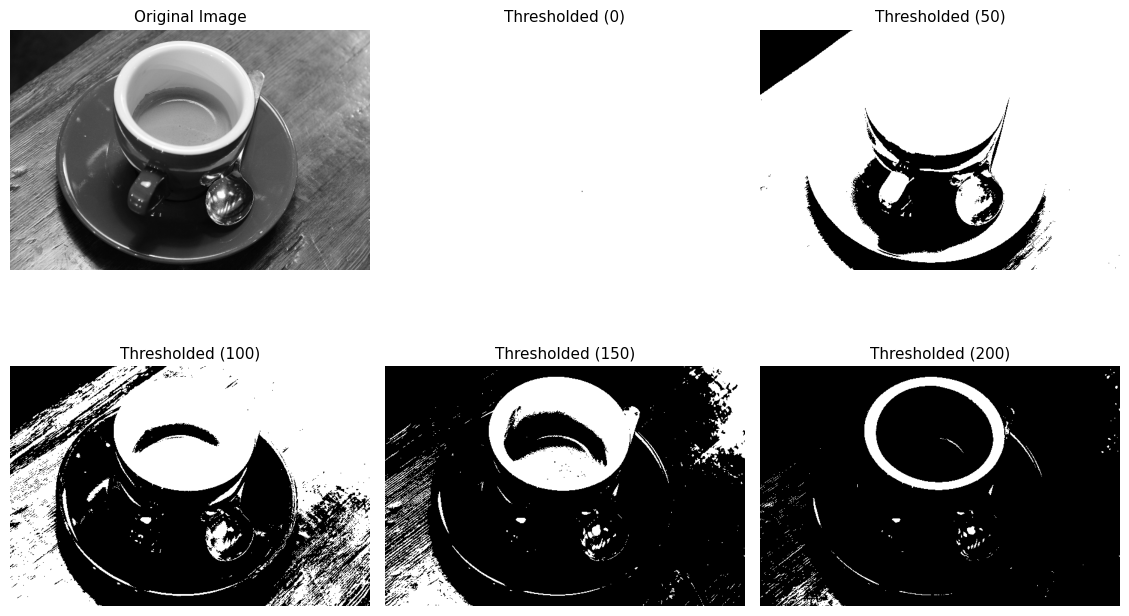

In [4]:
# Load the image in grayscale
img = cv2.imread(img_path('Parrot.png'), cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: the image could not be read")
else:
    print("shape:", img.shape, "| dtype:", img.dtype,
          "| range:", img.min(), "-", img.max())

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
results, titles = [img], ['Original Image']
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    results.append(thresh)
    titles.append(f'Thresholded ({threshold_value})')

show(results, titles, cols=3, size=3.8)

### 1.2 Reading the results

The proportion of white pixels tells the story more precisely than the images do.

In [5]:
print(f"{'threshold':<12}{'white pixels':>14}{'% white':>10}")
print("-" * 36)
for t in threshold_values:
    _, th = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
    print(f"{t:<12}{int((th > 0).sum()):>14}{100 * (th > 0).mean():>9.1f}%")

threshold     white pixels   % white
------------------------------------
0                   239998    100.0%
50                  189667     79.0%
100                 122212     50.9%
150                  48317     20.1%
200                  13589      5.7%


Two things are worth noting.

**A threshold of 0 is not a no-op, and it is not "everything white" either.** `THRESH_BINARY`
sets a pixel to 255 when it is **strictly greater** than the threshold, so with a threshold of 0
every pixel except the pure-black ones turns white. The result is almost entirely white, and
the few black pixels that remain are exactly the pixels whose value is 0.

**The useful threshold depends entirely on the image.** As the threshold rises, more of the
image falls below it and turns black. There is no value that is correct in general — which is
precisely the difficulty the manual describes, and the reason the automatic methods in 1.4
and 1.5 exist.

In [6]:
print("pixels exactly equal to 0 in the original:", int((img == 0).sum()))
_, th0 = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY)
print("black pixels after thresholding at 0     :", int((th0 == 0).sum()))
print("the two match:", int((img == 0).sum()) == int((th0 == 0).sum()))

pixels exactly equal to 0 in the original: 2
black pixels after thresholding at 0     : 2
the two match: True


### 1.3 The other thresholding types

`cv2.threshold` offers more than the binary form. These do not all produce binary images —
`TRUNC` and `TOZERO` keep the original intensities in part of the range.

| Type | Behaviour |
|---|---|
| `THRESH_BINARY` | above → 255, below → 0 |
| `THRESH_BINARY_INV` | the inverse of the above |
| `THRESH_TRUNC` | above → threshold, below unchanged |
| `THRESH_TOZERO` | above unchanged, below → 0 |
| `THRESH_TOZERO_INV` | above → 0, below unchanged |

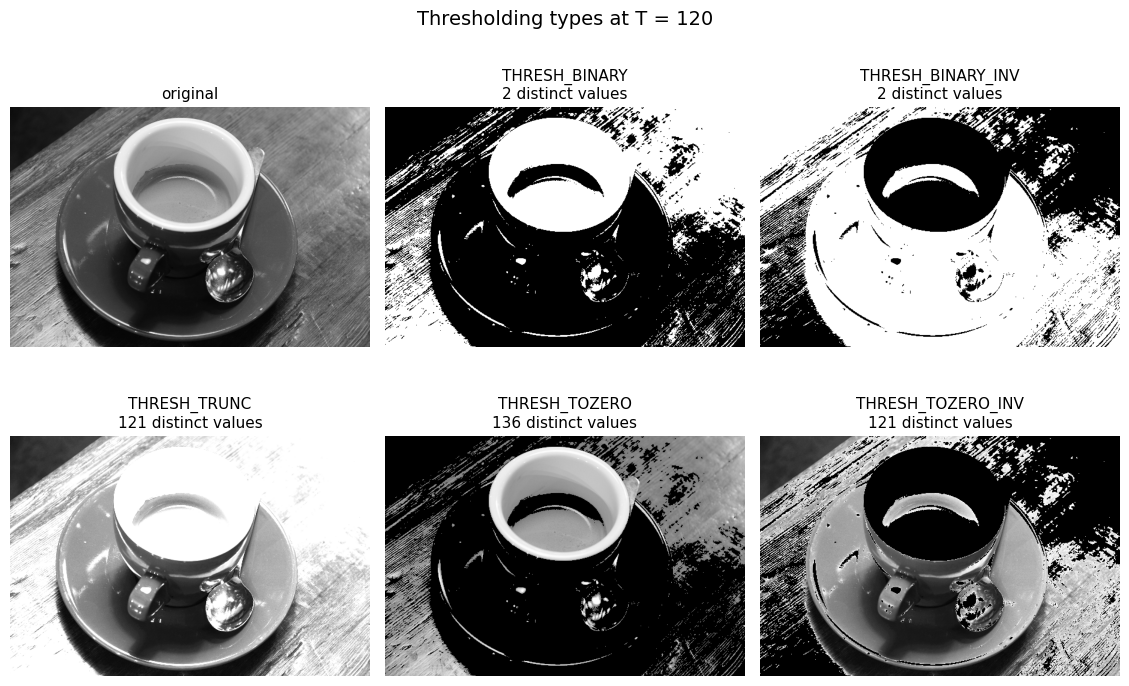

In [7]:
T = 120
types = [(cv2.THRESH_BINARY, 'THRESH_BINARY'),
         (cv2.THRESH_BINARY_INV, 'THRESH_BINARY_INV'),
         (cv2.THRESH_TRUNC, 'THRESH_TRUNC'),
         (cv2.THRESH_TOZERO, 'THRESH_TOZERO'),
         (cv2.THRESH_TOZERO_INV, 'THRESH_TOZERO_INV')]

imgs, titles = [img], ['original']
for flag, name in types:
    _, out = cv2.threshold(img, T, 255, flag)
    imgs.append(out)
    titles.append(f'{name}\n{len(np.unique(out))} distinct values')

show(imgs, titles, cols=3, size=3.8, suptitle=f'Thresholding types at T = {T}')

### 1.4 Choosing the threshold automatically — Otsu's method

The manual notes that picking a threshold is difficult because it depends on lighting and on
the objects of interest. **Otsu's method** removes the guesswork: it examines the histogram
and selects the value that best separates the pixels into two groups, by maximising the
variance *between* the groups.

It works well when the histogram has two distinct peaks — one for the objects, one for the
background. The `coins` image is the classic case, so it is included here alongside our own.

threshold chosen automatically by Otsu: 104.0
Otsu threshold for the coins image    : 107.0


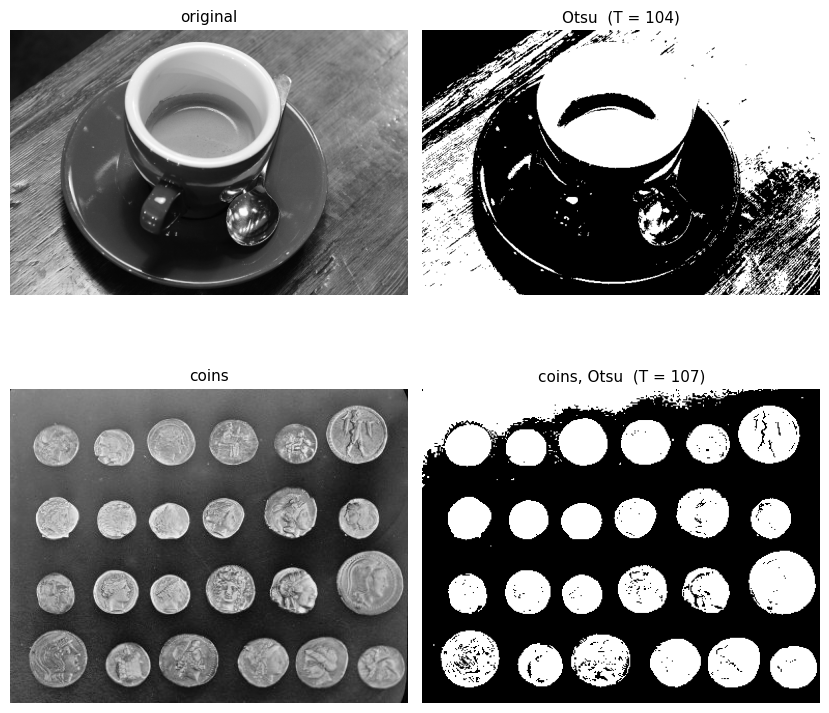

In [8]:
otsu_value, otsu_img = cv2.threshold(img, 0, 255,
                                     cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("threshold chosen automatically by Otsu:", otsu_value)

coins = data.coins()
coins_value, coins_otsu = cv2.threshold(coins, 0, 255,
                                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Otsu threshold for the coins image    :", coins_value)

show([img, otsu_img, coins, coins_otsu],
     ['original', f'Otsu  (T = {otsu_value:.0f})',
      'coins', f'coins, Otsu  (T = {coins_value:.0f})'],
     cols=2, size=4.2)

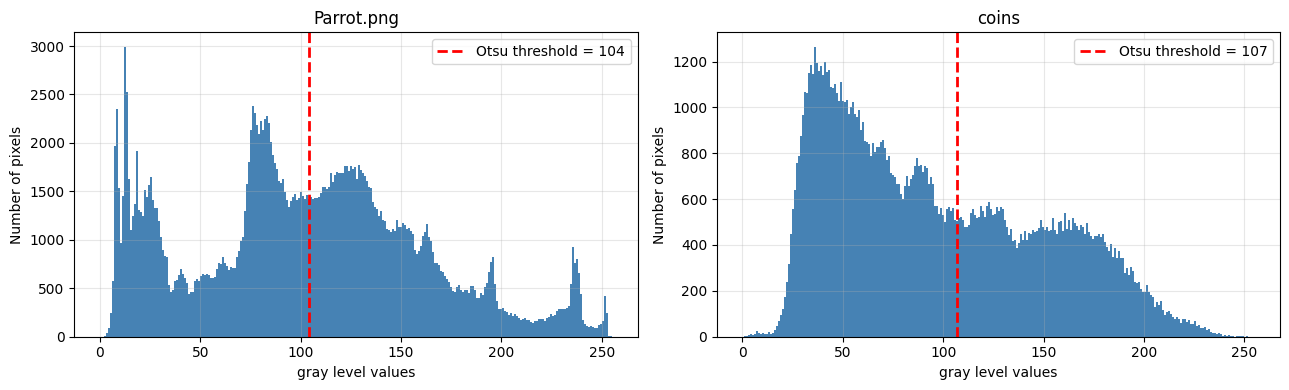

In [9]:
# where Otsu placed the threshold on the histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, im, t, name in [(axes[0], img, otsu_value, 'Parrot.png'),
                        (axes[1], coins, coins_value, 'coins')]:
    ax.hist(im.ravel(), bins=256, range=(0, 255), color='steelblue')
    ax.axvline(t, color='red', linestyle='--', linewidth=2,
               label=f'Otsu threshold = {t:.0f}')
    ax.set_title(name)
    ax.set_xlabel('gray level values')
    ax.set_ylabel('Number of pixels')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The coins histogram has two clear peaks and Otsu lands neatly in the valley between them,
which is why the segmentation is clean. Our own image has a less separated histogram, so the
same method gives a reasonable but less decisive result. Otsu is only as good as the
assumption that the image really does contain two populations of pixels.

### 1.5 Adaptive thresholding

The manual mentions adaptive thresholding, where the threshold **varies across the image**.
This matters whenever the lighting is uneven: a single global value will over-expose one side
of the image and under-expose the other, no matter how carefully it is chosen.

The cell below builds that situation deliberately by multiplying the image with a brightness
gradient, then compares a global threshold with an adaptive one.

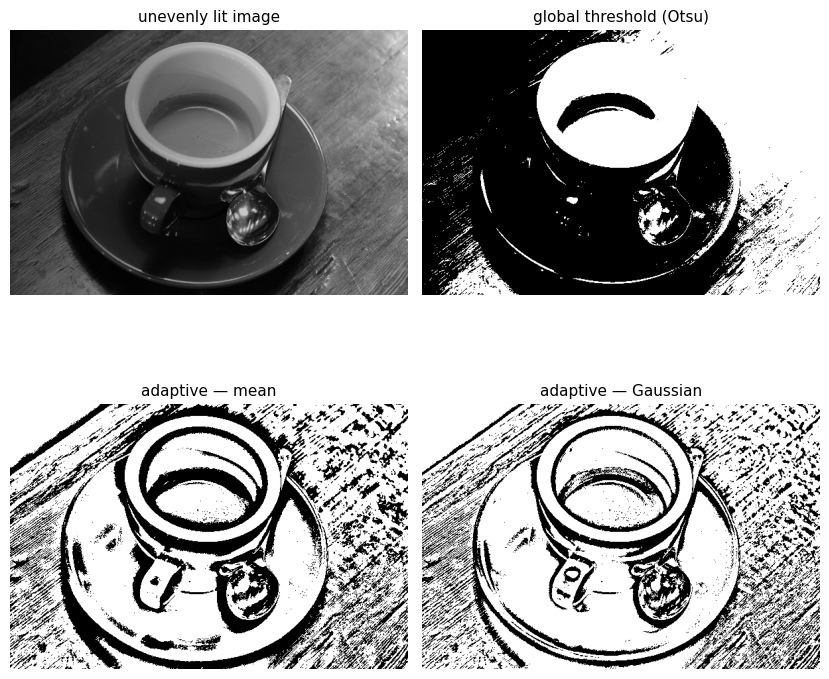

In [10]:
# create uneven illumination: a left-to-right brightness ramp
h, w = img.shape
ramp = np.linspace(0.35, 1.0, w).reshape(1, w)
uneven = np.clip(img.astype(np.float64) * ramp, 0, 255).astype(np.uint8)

_, global_th = cv2.threshold(uneven, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

adaptive_mean = cv2.adaptiveThreshold(uneven, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                      cv2.THRESH_BINARY, 35, 5)
adaptive_gauss = cv2.adaptiveThreshold(uneven, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY, 35, 5)

show([uneven, global_th, adaptive_mean, adaptive_gauss],
     ['unevenly lit image', 'global threshold (Otsu)',
      'adaptive — mean', 'adaptive — Gaussian'],
     cols=2, size=4.2)

The global threshold fails exactly as expected: the darkened left side falls below it almost
entirely and turns black, while the bright right side stays white. The adaptive versions
compute a separate threshold for each neighbourhood, so detail survives across the whole
frame.

---
## Part 2 — Histogram processing

A histogram counts how many pixels hold each intensity value. It says nothing about *where*
those pixels are, but it describes the tonal character of the image completely — and most
contrast operations are best understood as reshaping it.

### 2.1 The moon image and its histogram

shape: (512, 512) | dtype: uint8
range: 0 - 255 | mean: 112.2 | std: 13.3


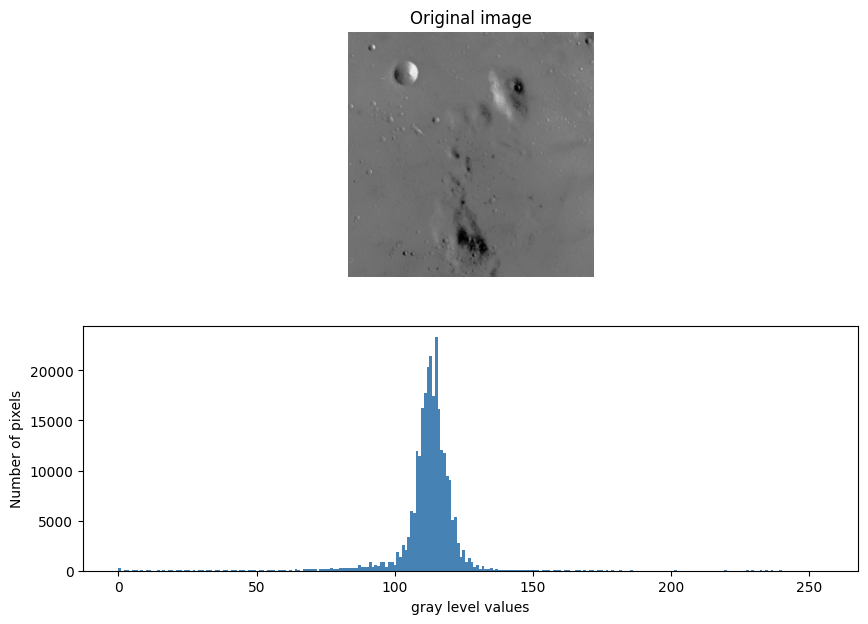

In [11]:
img_moon = data.moon()

print("shape:", img_moon.shape, "| dtype:", img_moon.dtype)
print("range:", img_moon.min(), "-", img_moon.max(),
      "| mean:", round(float(img_moon.mean()), 1),
      "| std:", round(float(img_moon.std()), 1))

show_with_hist(img_moon, 'Original image')

The image looks flat and washed out, and the histogram explains why: although the values do
reach 0 and 255, almost every pixel is packed into a narrow band in the middle. The full range
is technically used, but only by a handful of outliers — so the visible contrast is poor.

In [12]:
p1, p99 = np.percentile(img_moon, (1, 99))
print("1st percentile  :", p1)
print("99th percentile :", p99)
print(f"-> 98% of the pixels lie between {p1:.0f} and {p99:.0f}, "
      f"a span of only {p99 - p1:.0f} of the 256 available levels")

1st percentile  : 58.0
99th percentile : 141.0
-> 98% of the pixels lie between 58 and 141, a span of only 83 of the 256 available levels


### 2.2 Contrast stretching — the 2nd to 98th percentiles

Contrast stretching takes a chosen input range and expands it to fill the full output range.
Using percentiles rather than the minimum and maximum means that a few extreme outliers
cannot dictate the result.

input range used : (78.0, 129.0)
output range     : 0 - 255
std before       : 13.33
std after        : 42.27


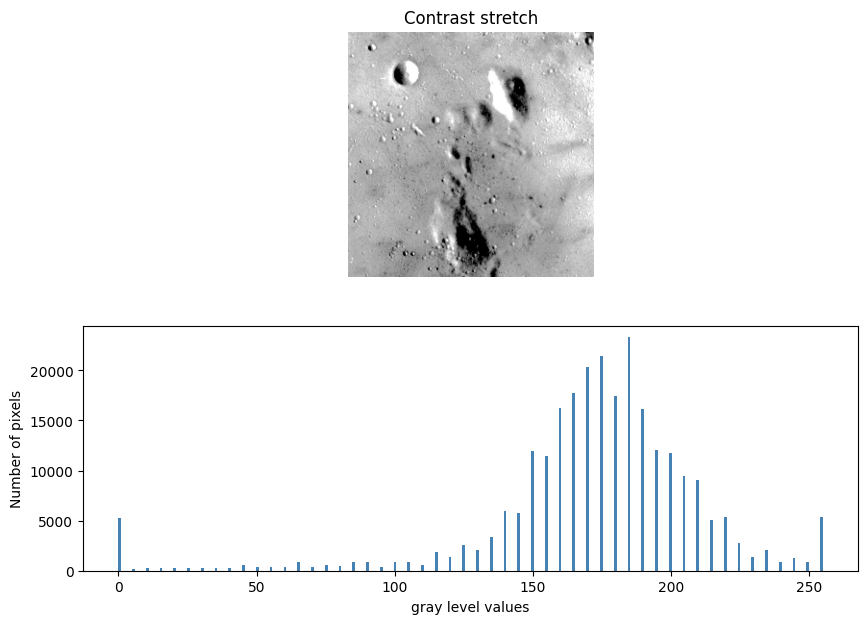

In [13]:
# Contrast stretching
p2, p98 = np.percentile(img_moon, (2, 98))
img_rescale = exposure.rescale_intensity(img_moon, in_range=(p2, p98))

print("input range used :", (round(float(p2), 1), round(float(p98), 1)))
print("output range     :", img_rescale.min(), "-", img_rescale.max())
print("std before       :", round(float(img_moon.std()), 2))
print("std after        :", round(float(img_rescale.std()), 2))

show_with_hist(img_rescale, 'Contrast stretch')

The histogram has been stretched across the full width, and the standard deviation — a
numerical measure of contrast — rises accordingly. The shape of the distribution is unchanged;
it has only been spread out. That is the defining property of contrast stretching, and what
separates it from the equalisation in Task 2.

Note also that pixels outside the 2nd–98th percentile range are **clipped**: everything below
`p2` becomes 0 and everything above `p98` becomes 255. Detail in those tails is lost, which is
the price of the extra contrast everywhere else.

In [14]:
below = int((img_moon < p2).sum())
above = int((img_moon > p98).sum())
print(f"pixels clipped to 0   : {below:>7}  ({100 * below / img_moon.size:.1f}%)")
print(f"pixels clipped to 255 : {above:>7}  ({100 * above / img_moon.size:.1f}%)")

pixels clipped to 0   :    5072  (1.9%)
pixels clipped to 255 :    4944  (1.9%)


---
## Task 1 — Rescale to the 3rd and 80th percentiles

The same operation with a different input range. The upper bound in particular is much more
aggressive: cutting at the 80th percentile instead of the 98th sends a large share of the
brightest pixels to pure white.

3rd percentile  : 87.0
80th percentile : 118.0
output range    : 0 - 255
std             : 55.46


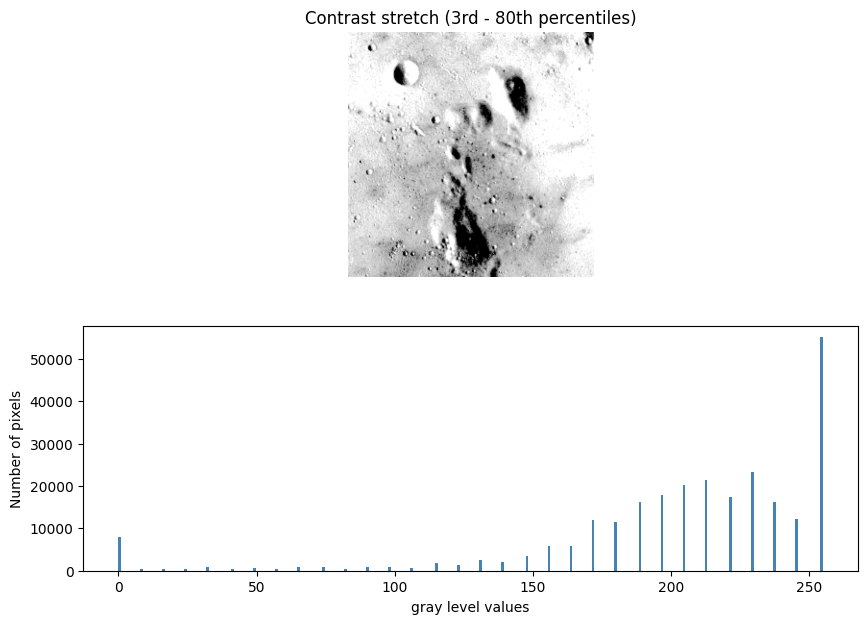

In [15]:
p3, p80 = np.percentile(img_moon, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img_moon, in_range=(p3, p80))

print("3rd percentile  :", round(float(p3), 1))
print("80th percentile :", round(float(p80), 1))
print("output range    :", img_rescale_3_80.min(), "-", img_rescale_3_80.max())
print("std             :", round(float(img_rescale_3_80.std()), 2))

show_with_hist(img_rescale_3_80, 'Contrast stretch (3rd - 80th percentiles)')

### Comparing the two ranges

version                     input range            std   clipped to 255
-----------------------------------------------------------------------
original                    0 - 255              13.33             0.0%
2nd - 98th percentiles      78 - 129             42.27             1.9%
3rd - 80th percentiles      87 - 118             55.46            16.5%


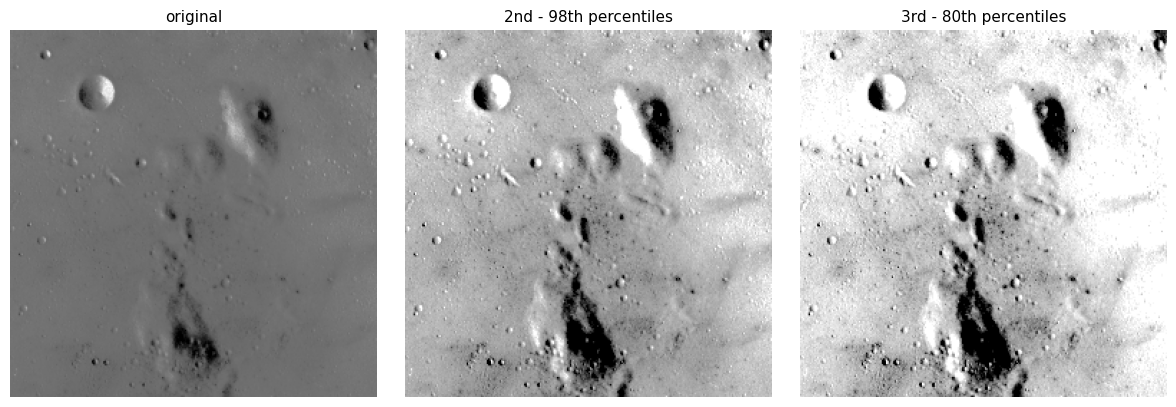

In [16]:
print(f"{'version':<28}{'input range':<18}{'std':>8}{'clipped to 255':>17}")
print("-" * 71)
for name, lo, hi, out in [("original", 0, 255, img_moon),
                          ("2nd - 98th percentiles", p2, p98, img_rescale),
                          ("3rd - 80th percentiles", p3, p80, img_rescale_3_80)]:
    clipped = 100 * (img_moon > hi).mean() if name != "original" else 0.0
    print(f"{name:<28}{f'{lo:.0f} - {hi:.0f}':<18}"
          f"{out.std():>8.2f}{clipped:>16.1f}%")

show([img_moon, img_rescale, img_rescale_3_80],
     ['original', '2nd - 98th percentiles', '3rd - 80th percentiles'],
     cols=3, size=4)

The 3rd–80th version has higher contrast in the mid-tones, but about one pixel in six is now
saturated to pure white with no detail left in it — against roughly one in fifty for the
2nd–98th version. (The figure is below the 20% that the 80th percentile suggests because many
pixels share the same value at the cut-off, and only those strictly above it are clipped.)
This is the central trade-off of
contrast stretching: every bit of contrast gained in the middle of the range is paid for by
detail lost at the ends. Which setting is "better" depends on where the information you care
about happens to sit.

---
## Task 2 — Histogram equalisation

`exposure.equalize_hist` does something fundamentally different from contrast stretching.
Rather than spreading the existing distribution out linearly, it **redistributes** the values so
that every intensity level ends up with roughly the same number of pixels — flattening the
histogram. It does this by using the cumulative distribution function of the image as the
transformation curve.

The result is strong contrast everywhere, but the mapping is non-linear, so the tonal
relationships between regions change.

### An important detail about the output type

`equalize_hist` returns a **float image with values between 0 and 1**, not `uint8` values
between 0 and 255. Plotting its histogram with `range=(0, 255)`, as the manual's plotting code
does for the original image, would put every pixel into the very first bin and produce an empty
chart. The `show_with_hist` helper reads the range from the data, which is why it works for
both. The cell below makes the difference explicit.

In [17]:
img_eq = exposure.equalize_hist(img_moon)

print("original  :", img_moon.dtype, "range", img_moon.min(), "-", img_moon.max())
print("equalised :", img_eq.dtype, "range",
      round(float(img_eq.min()), 4), "-", round(float(img_eq.max()), 4))
print()
counts, _ = np.histogram(img_eq, bins=256, range=(0, 255))
print("if plotted with range=(0, 255):")
print("   pixels landing in the first bin :", int(counts[0]),
      f"({100 * counts[0] / img_eq.size:.1f}% of the image)")
print("   pixels in all the other bins    :", int(counts[1:].sum()))

original  : uint8 range 0 - 255
equalised : float64 range 0.0009 - 1.0

if plotted with range=(0, 255):
   pixels landing in the first bin : 261096 (99.6% of the image)
   pixels in all the other bins    : 1048


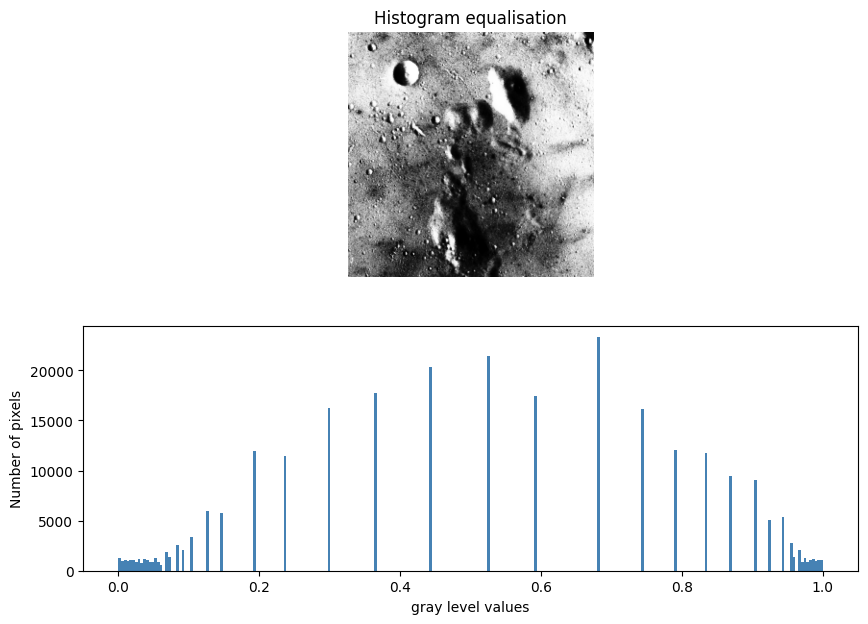

In [18]:
show_with_hist(img_eq, 'Histogram equalisation')

### Why the histogram is not perfectly flat

The histogram above is spread across the whole range but still spiky. This is a property of
equalising a **discrete** image, not a mistake. All the pixels sharing one input value are mapped
to the same output value — they cannot be split apart — so a tall spike in the input stays a
tall spike in the output, just relocated. True flatness is only achievable for continuous data.

The *cumulative* histogram is the right place to look: for a perfectly equalised image it is a
straight diagonal line.

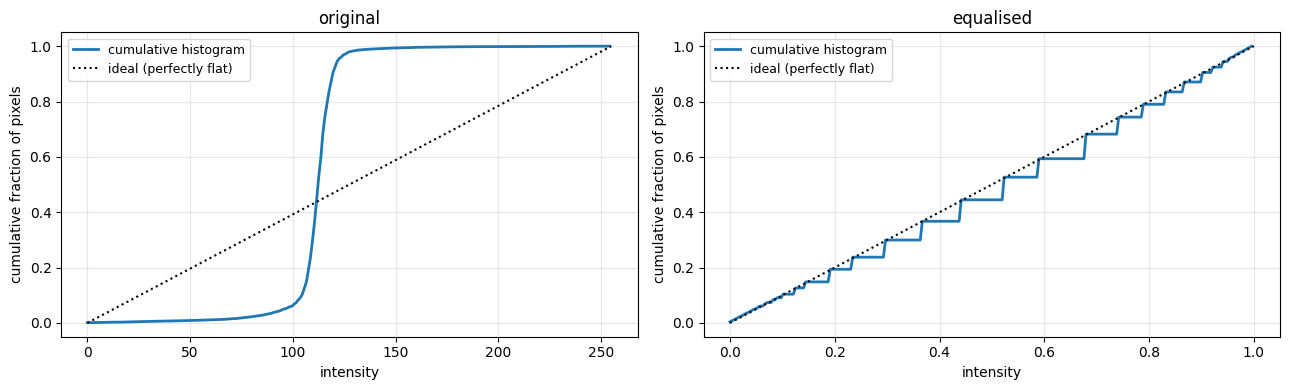

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, im, name in [(axes[0], img_moon, 'original'),
                     (axes[1], img_eq, 'equalised')]:
    vals = im.ravel()
    lo, hi = (0, 255) if im.dtype == np.uint8 else (0, 1)
    hist, edges = np.histogram(vals, bins=256, range=(lo, hi))
    cdf = np.cumsum(hist) / hist.sum()
    ax.plot(edges[:-1], cdf, linewidth=2, label='cumulative histogram')
    ax.plot([lo, hi], [0, 1], 'k:', linewidth=1.5, label='ideal (perfectly flat)')
    ax.set_title(name)
    ax.set_xlabel('intensity')
    ax.set_ylabel('cumulative fraction of pixels')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Comparing all three contrast methods

Adaptive equalisation (CLAHE) is included for completeness — it applies equalisation to small
tiles rather than to the whole image, which keeps local detail without over-amplifying the
global contrast.

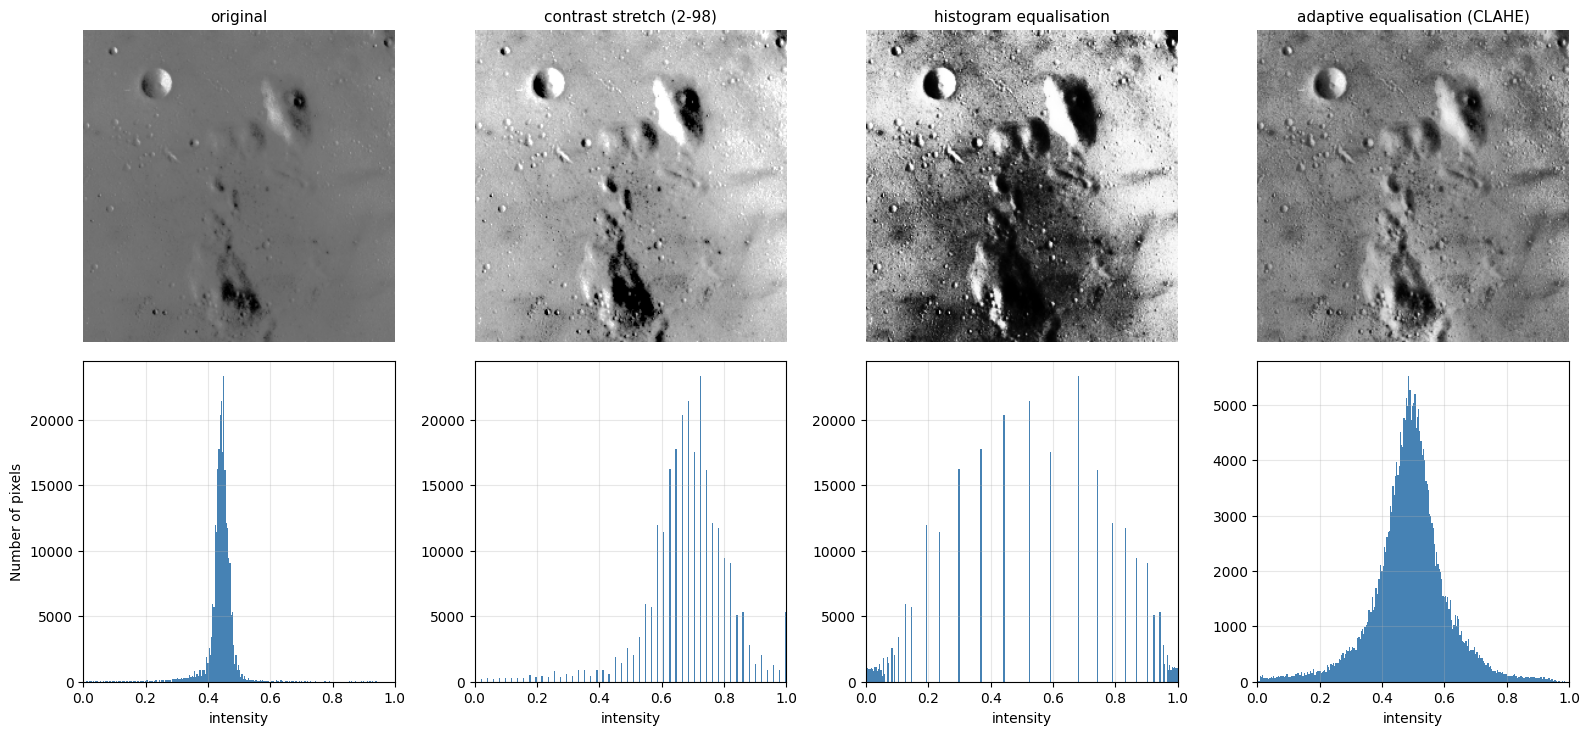

original                         std = 0.0523
contrast stretch (2-98)          std = 0.1658
histogram equalisation           std = 0.2896
adaptive equalisation (CLAHE)    std = 0.1195


In [20]:
img_adapteq = exposure.equalize_adapthist(img_moon, clip_limit=0.03)

versions = [(img_as_float(img_moon), 'original'),
            (img_as_float(img_rescale), 'contrast stretch (2-98)'),
            (img_eq, 'histogram equalisation'),
            (img_adapteq, 'adaptive equalisation (CLAHE)')]

fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
for k, (im, t) in enumerate(versions):
    axes[0, k].imshow(im, cmap='gray')
    axes[0, k].set_title(t, fontsize=11)
    axes[0, k].axis('off')
    axes[1, k].hist(im.ravel(), bins=256, range=(0, 1), color='steelblue')
    axes[1, k].set_xlim(0, 1)
    axes[1, k].set_xlabel('intensity')
    axes[1, k].grid(alpha=0.3)
axes[1, 0].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()

for im, t in versions:
    print(f"{t:<32} std = {im.std():.4f}")

---
## Task 3 — Histogram matching

Histogram matching is the general case of the previous two. Instead of stretching a
distribution or flattening it, it reshapes the histogram of one image so that it matches the
histogram of a **reference** image. The input keeps its own content; it takes on the reference's
tonal character.

Here the **rocket** image is the reference and **Chelsea** is the input, as the task specifies.
Both are colour images, so the matching is done channel by channel — which is what the
`channel_axis` argument is for.

reference (rocket) : (427, 640, 3) uint8
input    (chelsea) : (300, 451, 3) uint8
matched            : (300, 451, 3) uint8


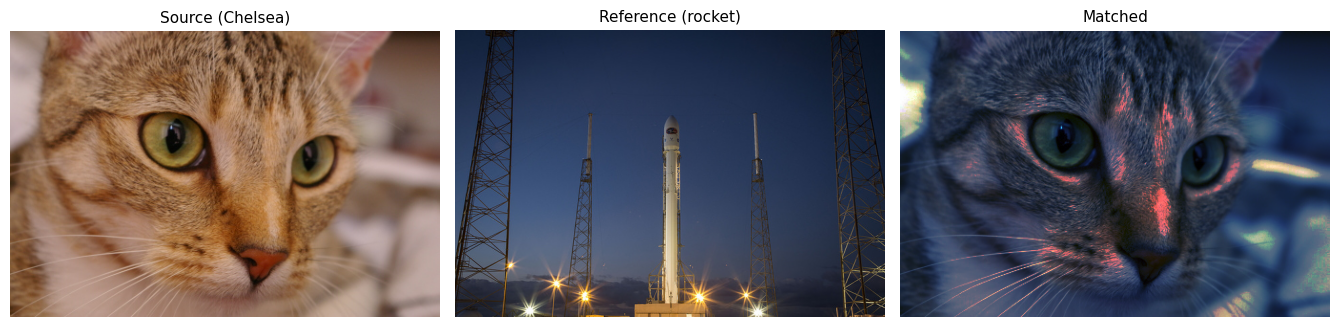

In [21]:
reference = data.rocket()     # reference — provides the target histogram
image = data.chelsea()        # input — keeps its content, takes the reference's tones

print("reference (rocket) :", reference.shape, reference.dtype)
print("input    (chelsea) :", image.shape, image.dtype)

matched = exposure.match_histograms(image, reference, channel_axis=-1)

print("matched            :", matched.shape, matched.dtype)

show([image, reference, matched],
     ['Source (Chelsea)', 'Reference (rocket)', 'Matched'],
     cols=3, size=4.5)

The matched image keeps the cat — its shapes and edges are untouched — but has taken on the
cooler, more contrasted tone of the rocket photograph. Nothing was copied between the images
except the *distribution of values*.

### Verifying the match on the cumulative histograms

The visual result is suggestive; the cumulative histograms are the proof. If the matching
worked, the curve for the matched image should lie on top of the reference's curve, not on the
source's.

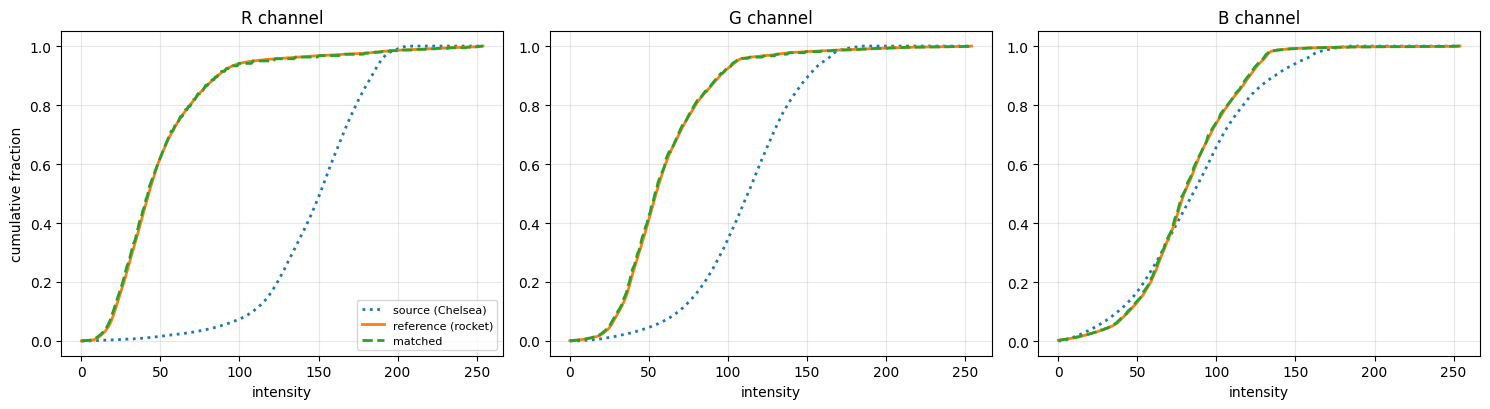

In [22]:
matched_u8 = img_as_ubyte(np.clip(matched / 255.0, 0, 1)) \
    if matched.dtype != np.uint8 else matched

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for c, (cname, colour) in enumerate(zip('RGB', ['red', 'green', 'blue'])):
    for arr, label, style in [(image, 'source (Chelsea)', ':'),
                              (reference, 'reference (rocket)', '-'),
                              (matched_u8, 'matched', '--')]:
        hist, edges = np.histogram(arr[..., c].ravel(), bins=256, range=(0, 255))
        cdf = np.cumsum(hist) / hist.sum()
        axes[c].plot(edges[:-1], cdf, style, linewidth=2, label=label)
    axes[c].set_title(f'{cname} channel')
    axes[c].set_xlabel('intensity')
    axes[c].grid(alpha=0.3)
axes[0].set_ylabel('cumulative fraction')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [23]:
# how closely the matched image reproduces the reference distribution
print(f"{'channel':<10}{'max |CDF difference| vs reference':>36}")
print("-" * 48)
for c, cname in enumerate('RGB'):
    def cdf_of(a):
        hh, _ = np.histogram(a[..., c].ravel(), bins=256, range=(0, 255))
        return np.cumsum(hh) / hh.sum()
    before = np.abs(cdf_of(image) - cdf_of(reference)).max()
    after = np.abs(cdf_of(matched_u8) - cdf_of(reference)).max()
    print(f"{cname:<10}{f'before {before:.3f}   ->   after {after:.3f}':>36}")

channel      max |CDF difference| vs reference
------------------------------------------------
R              before 0.868   ->   after 0.019
G              before 0.645   ->   after 0.017
B              before 0.091   ->   after 0.015


The maximum distance between the cumulative distributions drops sharply in every channel.
It does not reach zero, and for the same reason the equalised histogram was not perfectly
flat: the images are discrete, so all pixels sharing an input value must share an output value
and the distribution can only be approximated.

### The three operations side by side

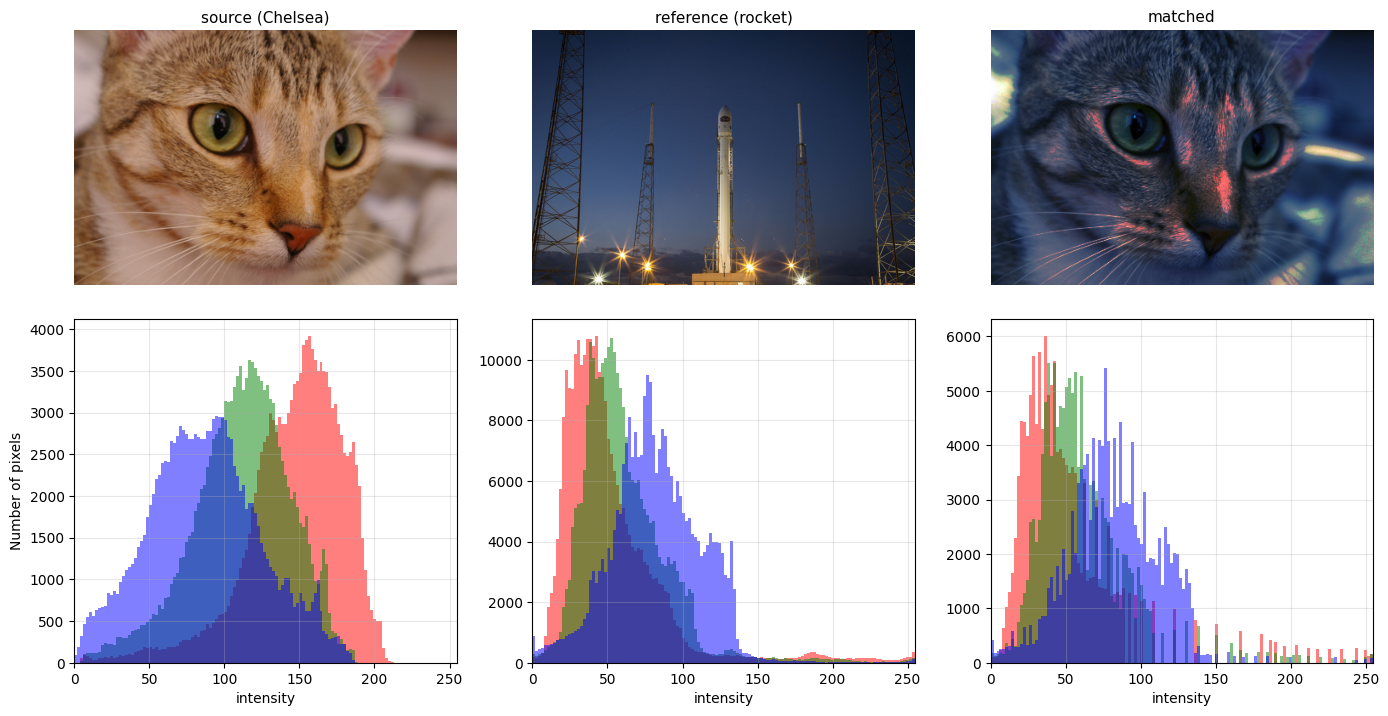

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for k, (im, t) in enumerate([(image, 'source (Chelsea)'),
                             (reference, 'reference (rocket)'),
                             (matched_u8, 'matched')]):
    axes[0, k].imshow(im)
    axes[0, k].set_title(t, fontsize=11)
    axes[0, k].axis('off')
    for c, colour in zip(range(3), ['red', 'green', 'blue']):
        axes[1, k].hist(im[..., c].ravel(), bins=128, range=(0, 255),
                        color=colour, alpha=0.5)
    axes[1, k].set_xlim(0, 255)
    axes[1, k].set_xlabel('intensity')
    axes[1, k].grid(alpha=0.3)
axes[1, 0].set_ylabel('Number of pixels')
plt.tight_layout()
plt.savefig('output/lab4_matching.png', dpi=110, bbox_inches='tight')
plt.show()

In [25]:
# summary figure for the report
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
summary = [(img, 'original (Parrot.png)'), (otsu_img, f'Otsu threshold ({otsu_value:.0f})'),
           (adaptive_gauss, 'adaptive threshold'),
           (img_moon, 'moon — original'), (img_rescale_3_80, 'stretch 3rd - 80th'),
           (img_eq, 'histogram equalisation')]
for ax, (im, t) in zip(axes.flat, summary):
    ax.imshow(im, cmap='gray')
    ax.set_title(t, fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.savefig('output/lab4_summary.png', dpi=110, bbox_inches='tight')
plt.close()
print("Saved: output/lab4_summary.png")
print("Saved: output/lab4_matching.png")

Saved: output/lab4_summary.png
Saved: output/lab4_matching.png


---
## Conclusion

**Thresholding** reduces an image to two values by comparing every pixel with a single number.
It is the simplest form of segmentation and the whole difficulty lies in choosing that number:
a threshold of 0 keeps almost everything, a high threshold discards almost everything, and no
fixed value transfers from one image to another. Otsu's method removes the guesswork by
selecting the value that best separates the histogram into two groups, which works well when
the image genuinely contains two populations of pixels — the `coins` image is the clean case,
and a photograph with a continuous histogram is the less decisive one. When the lighting is
uneven, no single global value can work at all, and adaptive thresholding computes a separate
threshold per neighbourhood instead.

**Histogram processing** covers three operations that differ in what they do to the
distribution of intensities. **Contrast stretching** maps a chosen input range onto the full
output range: the shape of the histogram is preserved, only spread out, and whatever falls
outside the chosen range is clipped. Narrowing the range from the 2nd–98th percentiles to the
3rd–80th raised the contrast in the mid-tones but saturated about one pixel in six to pure
white — contrast gained in the middle is always paid for with detail lost at the ends.
**Equalisation** instead reshapes the distribution so that every level holds roughly the same
number of pixels, using the cumulative distribution as the transformation curve. **Matching**
is the general case: it reshapes the histogram of one image to follow that of a reference,
which is how two photographs taken under different conditions are brought to a common tonal
character.

Two implementation details came out of the work. `exposure.equalize_hist` returns a **float
image in the range 0 to 1**, not `uint8` in 0–255, so a histogram plotted with the range
hard-coded to `(0, 255)` collapses into a single bin and appears empty — the display helper
reads the range from the data instead. And `exposure.match_histograms` takes **`channel_axis`**
for colour images; the `multichannel` argument used in older tutorials has been removed from
current scikit-image.

Finally, neither equalisation nor matching produces an exact result, and for the same reason
in both cases: the images are discrete. All the pixels sharing one input value are mapped to a
single output value and cannot be separated, so the target distribution can only be
approximated — which is why the equalised histogram stays spiky and the matched cumulative
curves come close to the reference without landing on it.

---

### Resources
- Hands-On Image Processing with Python (course book)
- https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_equalize.html
- https://scikit-image.org/docs/0.24.x/auto_examples/color_exposure/plot_histogram_matching.html
- OpenCV thresholding: https://docs.opencv.org/